# 06 Final Model Selection and Evaluation

## 1. Objective and Scope

This notebook  
  
- compares the three tuned candidate models on the 2024 validation partition  
- selects and freezes one final model configuration  
- evaluates it once on the untouched 2025 locked test partition  
  
The 2026 scoring dataset remains untouched until Notebook 07.

## 2. Load the Evaluation Inputs

### 2.1 Import Libraries and Set Configuration

This section imports the libraries required to load the saved candidate pipelines, evaluate model predictions, refit the selected configuration, and export the final modelling artifacts.

The dataset roles and evaluation metrics are defined before any validation or test predictions are generated. MAE remains the primary model-selection metric, while RMSE is retained as a secondary diagnostic.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
)
from sklearn.inspection import permutation_importance


# Fixed dataset roles and evaluation seasons
TRAINING_ROLE = "training"
VALIDATION_ROLE = "validation"
LOCKED_TEST_ROLE = "locked_test"

VALIDATION_SEASON = 2024
LOCKED_TEST_SEASON = 2025


# Evaluation hierarchy
PRIMARY_SELECTION_METRIC = "MAE"
SECONDARY_DIAGNOSTIC_METRIC = "RMSE"


# Display configuration
pd.set_option("display.max_columns", None)

### 2.2 Load and Validate the Model and Data Artifacts

The three candidate pipelines and tuning summary produced by Notebook 05 are loaded alongside the historical model dataset created in Notebook 04.

Only the artifact structure, feature definitions, and fixed dataset-role counts are checked at this stage. The 2025 locked test features and target are not isolated or used for prediction.

**Load three files (model, tuning summary, and historical model dataset)**

In [2]:
# Resolve the project root whether the notebook starts from the
# repository root or from the notebooks directory.
project_root = Path.cwd().resolve()

if project_root.name.lower() == "notebooks":
    project_root = project_root.parent


# Define the required Notebook 06 input paths.
candidate_model_path = (
    project_root
    / "models"
    / "candidates"
    / "notebook_05_candidate_models.joblib"
)

tuning_summary_path = (
    project_root
    / "reports"
    / "modeling"
    / "notebook_05_candidate_tuning_summary.csv"
)

historical_data_path = (
    project_root
    / "data"
    / "processed"
    / "historical_model_dataset.csv"
)


# Confirm that all required inputs are available.
input_artifact_paths = {
    "Candidate model bundle": candidate_model_path,
    "Candidate tuning summary": tuning_summary_path,
    "Historical model dataset": historical_data_path,
}

missing_artifacts = [
    str(path)
    for path in input_artifact_paths.values()
    if not path.exists()
]

if missing_artifacts:
    raise FileNotFoundError(
        "Required Notebook 06 inputs were not found:\n"
        + "\n".join(missing_artifacts)
    )


# Load the Notebook 05 model artifacts.
candidate_model_bundle = joblib.load(
    candidate_model_path
)

tuning_summary_df = pd.read_csv(
    tuning_summary_path
)


# Load the historical modelling dataset.
historical_df = pd.read_csv(
    historical_data_path,
    parse_dates=["match_date"],
)

**Validate the model and data artifact**

In [3]:
# Unpack the modelling inputs required by Notebook 06.
candidate_estimators = (
    candidate_model_bundle["estimators"]
)

selected_parameters = (
    candidate_model_bundle["selected_parameters"]
)

FEATURE_COLUMNS = (
    candidate_model_bundle["feature_columns"]
)

TARGET_COLUMN = (
    candidate_model_bundle["target_column"]
)


# Define the expected candidate-model set.
expected_model_keys = {
    "ridge",
    "random_forest",
    "gradient_boosting",
}


# Check the candidate model artifacts.
candidate_artifacts_valid = (
    set(candidate_estimators)
    == expected_model_keys
    and set(selected_parameters)
    == expected_model_keys
)


# Check that the tuning summary covers the same models.
tuning_summary_valid = (
    "model_key" in tuning_summary_df.columns
    and set(tuning_summary_df["model_key"])
    == expected_model_keys
)


# Check the feature and target contract.
required_model_columns = (
    FEATURE_COLUMNS
    + [
        TARGET_COLUMN,
        "match_date",
        "season_year",
        "dataset_role",
    ]
)

model_schema_valid = (
    len(FEATURE_COLUMNS) == 17
    and len(FEATURE_COLUMNS)
    == len(set(FEATURE_COLUMNS))
    and set(required_model_columns).issubset(
        historical_df.columns
    )
)


# Check the fixed project-level dataset roles.
expected_role_counts = {
    TRAINING_ROLE: 1865,
    VALIDATION_ROLE: 216,
    LOCKED_TEST_ROLE: 216,
}

actual_role_counts = (
    historical_df["dataset_role"]
    .value_counts()
    .to_dict()
)

dataset_roles_valid = (
    actual_role_counts
    == expected_role_counts
)


# Check that MAE remains the primary selection metric.
selection_metric_valid = (
    str(
        candidate_model_bundle["selection_metric"]
    ).upper()
    == PRIMARY_SELECTION_METRIC
)


# Present one concise input-validation table.
input_checks = {
    "Candidate model artifacts": candidate_artifacts_valid,
    "Tuning summary": tuning_summary_valid,
    "Feature and target schema": model_schema_valid,
    "Fixed dataset roles": dataset_roles_valid,
    "Primary selection metric": selection_metric_valid,
}

input_check_summary = pd.DataFrame(
    [
        {
            "check": check_name,
            "result": (
                "PASS"
                if check_passed
                else "FAIL"
            ),
        }
        for check_name, check_passed
        in input_checks.items()
    ]
)

display(input_check_summary)


# Stop before evaluation if an input check failed.
if input_check_summary[
    "result"
].eq("FAIL").any():
    raise ValueError(
        "One or more Notebook 06 input checks failed."
    )

,check,result
0,Candidate model artifacts,PASS
1,Tuning summary,PASS
2,Feature and target schema,PASS
3,Fixed dataset roles,PASS
4,Primary selection metric,PASS


## 3. Compare Candidate Models on 2024 Validation Data

### 3.1 Prepare the 2024 Validation Data

The fixed 2024 validation partition is isolated and arranged chronologically. Its model features and attendance target are prepared using the feature contract loaded from the Notebook 05 candidate bundle.

No preprocessing or model fitting is performed on the validation data. Each saved candidate pipeline will apply the preprocessing learned from the original training partition when generating predictions.

The 2025 locked test partition remains untouched.

In [4]:
# Isolate and chronologically order the 2024 validation partition.
validation_df = (
    historical_df
    .loc[
        historical_df["dataset_role"].eq(
            VALIDATION_ROLE
        )
    ]
    .copy()
    .sort_values(
        "match_date",
        kind="stable",
    )
    .reset_index(drop=True)
)


# Confirm the expected validation coverage.
validation_seasons = sorted(
    validation_df["season_year"]
    .unique()
    .tolist()
)

if (
    len(validation_df) != 216
    or validation_seasons != [VALIDATION_SEASON]
):
    raise ValueError(
        "The 2024 validation partition does not "
        "match the expected project design."
    )


# Construct the validation feature matrix and target vector.
X_validation = (
    validation_df
    .loc[:, FEATURE_COLUMNS]
    .copy()
)

y_validation = (
    validation_df
    .loc[:, TARGET_COLUMN]
    .astype("float64")
    .copy()
)


# Confirm that the validation inputs are ready.
if (
    X_validation.shape[1] != 17
    or y_validation.isna().any()
):
    raise ValueError(
        "The validation model inputs are not ready."
    )


# Present a concise validation-input summary.
validation_input_summary = pd.DataFrame(
    [
        {
            "dataset_role": VALIDATION_ROLE,
            "rows": len(validation_df),
            "season": validation_seasons[0],
            "features": X_validation.shape[1],
            "missing_feature_values": int(
                X_validation.isna().sum().sum()
            ),
            "missing_target_values": int(
                y_validation.isna().sum()
            ),
        }
    ]
)

validation_input_summary

,dataset_role,rows,season,features,missing_feature_values,missing_target_values
0,validation,216,2024,17,0,0


### 3.2 Generate Predictions and Compare Performance

Each of the three candidate pipelines generates predictions for the same 216 matches in the 2024 validation partition. The pipelines already contain the preprocessing and model configuration fitted in Notebook 05, so no additional fitting or hyperparameter tuning is performed.

Candidate performance is compared using MAE as the primary selection metric and RMSE as a secondary diagnostic. Lower values indicate better validation performance.

In [5]:
# Create a reader-friendly model-name lookup.
model_name_lookup = (
    tuning_summary_df
    .set_index("model_key")["model_name"]
    .to_dict()
)


# Generate and retain validation predictions for each candidate.
validation_predictions = {}
validation_result_records = []

for model_key, estimator in candidate_estimators.items():
    predictions = np.asarray(
        estimator.predict(X_validation),
        dtype="float64",
    )

    if (
        len(predictions) != len(y_validation)
        or not np.isfinite(predictions).all()
    ):
        raise ValueError(
            f"Invalid validation predictions: "
            f"{model_key}"
        )

    validation_predictions[model_key] = predictions

    validation_result_records.append(
        {
            "model_key": model_key,
            "model_name": model_name_lookup[model_key],
            "validation_mae": mean_absolute_error(
                y_validation,
                predictions,
            ),
            "validation_rmse": root_mean_squared_error(
                y_validation,
                predictions,
            ),
        }
    )


# Create the candidate-comparison table.
validation_results_df = (
    pd.DataFrame(validation_result_records)
    .sort_values(
        [
            "validation_mae",
            "validation_rmse",
        ]
    )
    .reset_index(drop=True)
)


# Round only the displayed copy.
validation_results_display = (
    validation_results_df.copy()
)

validation_results_display[
    [
        "validation_mae",
        "validation_rmse",
    ]
] = (
    validation_results_display[
        [
            "validation_mae",
            "validation_rmse",
        ]
    ]
    .round(2)
)

validation_results_display

,model_key,model_name,validation_mae,validation_rmse
0,gradient_boosting,Gradient Boosting Regressor,5471.35,7719.31
1,random_forest,Random Forest Regressor,6462.30,9176.80
2,ridge,Ridge Regression,6751.06,9409.48


### 3.3 Select and Freeze the Final Model

The final model family is selected using the predefined evaluation rule: the lowest 2024 validation MAE, with RMSE retained as a secondary diagnostic.

The selected model family and its existing Notebook 05 hyperparameter configuration are frozen before the 2025 locked test partition is accessed. The locked-test result will therefore be used only to estimate final generalisation performance, not to revise the model-selection decision.

In [6]:
# Apply the predefined selection rule:
# lowest validation MAE, followed by validation RMSE.
selected_result = (
    validation_results_df
    .sort_values(
        [
            "validation_mae",
            "validation_rmse",
        ]
    )
    .iloc[0]
)


# Retain the selected model and its Notebook 05 configuration.
selected_model_key = selected_result["model_key"]
selected_model_name = selected_result["model_name"]

selected_candidate_pipeline = (
    candidate_estimators[selected_model_key]
)

selected_model_parameters = (
    selected_parameters[selected_model_key]
)


# Record the frozen selection decision.
frozen_selection = {
    "model_key": selected_model_key,
    "model_name": selected_model_name,
    "validation_mae": float(
        selected_result["validation_mae"]
    ),
    "validation_rmse": float(
        selected_result["validation_rmse"]
    ),
    "selected_hyperparameters": "; ".join(
        f"{name}={value}"
        for name, value
        in selected_model_parameters.items()
    ),
    "selection_status": (
        "Frozen before 2025 locked-test access"
    ),
}


# Present the decision in a reader-friendly table.
frozen_selection_display = pd.DataFrame(
    [frozen_selection]
)

frozen_selection_display[
    [
        "validation_mae",
        "validation_rmse",
    ]
] = (
    frozen_selection_display[
        [
            "validation_mae",
            "validation_rmse",
        ]
    ]
    .round(2)
)

frozen_selection_display

,model_key,model_name,validation_mae,validation_rmse,selected_hyperparameters,selection_status
0,gradient_boosting,Gradient Boosting Regressor,5471.35,7719.31,learning_rate=0.1; max_depth=3; min_samples_le...,Frozen before 2025 locked-test access


**The Final Model:**

Gradient Boosting Regressor is selected as the final model family. It achieved the lowest 2024 validation MAE of 5,471 attendees and the lowest RMSE of 7,719 attendees.

Its validation MAE was approximately 15.3% lower than Random Forest, the next-best candidate, and approximately 19.0% lower than Ridge Regression. The result is also consistent with the internal cross-validation ranking from Notebook 05.

The selected Gradient Boosting configuration is now frozen:

- `learning_rate=0.1`
- `max_depth=3`
- `min_samples_leaf=2`
- `n_estimators=500`

No model-family change or further hyperparameter tuning will be permitted after the 2025 locked test partition is accessed.

## 4. Refit the Selected Model

### 4.1 Refit the Selected Configuration on Development Data

After the model-selection decision is frozen, the original training partition and the 2024 validation partition are combined into one expanded development dataset.

A fresh copy of the selected pipeline is fitted on these data using exactly the same preprocessing design and hyperparameter configuration selected in Notebook 05. No additional hyperparameter search is performed.

This allows the final evaluation model to use all information available through the end of 2024 while preserving the 2025 season as an untouched test of one-season-ahead generalisation.

In [7]:
# Combine the original training and 2024 validation partitions.
development_df = (
    historical_df
    .loc[
        historical_df["dataset_role"].isin(
            [
                TRAINING_ROLE,
                VALIDATION_ROLE,
            ]
        )
    ]
    .copy()
    .sort_values(
        "match_date",
        kind="stable",
    )
    .reset_index(drop=True)
)


# Confirm the expected development-data coverage.
development_seasons = sorted(
    development_df["season_year"]
    .unique()
    .tolist()
)

expected_development_seasons = [
    2013,
    2014,
    2015,
    2016,
    2017,
    2018,
    2019,
    2022,
    2023,
    2024,
]

if (
    len(development_df) != 2081
    or development_seasons
    != expected_development_seasons
):
    raise ValueError(
        "The expanded development dataset does not "
        "match the expected project design."
    )


# Construct the expanded development inputs.
X_development = (
    development_df
    .loc[:, FEATURE_COLUMNS]
    .copy()
)

y_development = (
    development_df
    .loc[:, TARGET_COLUMN]
    .astype("float64")
    .copy()
)

if y_development.isna().any():
    raise ValueError(
        "The development target contains missing values."
    )


# Create a fresh copy of the frozen pipeline configuration.
final_model_pipeline = clone(
    selected_candidate_pipeline
)


# Refit the selected configuration without further tuning.
final_model_pipeline.fit(
    X_development,
    y_development,
)


# Confirm that the selected hyperparameters were preserved.
refitted_model_parameters = (
    final_model_pipeline
    .named_steps["model"]
    .get_params()
)

configuration_preserved = all(
    refitted_model_parameters[parameter_name]
    == selected_value
    for parameter_name, selected_value
    in selected_model_parameters.items()
)

if not configuration_preserved:
    raise ValueError(
        "The frozen model configuration was not preserved."
    )


# Confirm that the refitted pipeline can generate predictions.
refit_smoke_predictions = (
    final_model_pipeline.predict(
        X_development.head(5)
    )
)

if not np.isfinite(
    refit_smoke_predictions
).all():
    raise ValueError(
        "The refitted pipeline produced invalid predictions."
    )


# Present a concise refitting summary.
refit_summary = pd.DataFrame(
    [
        {
            "model": selected_model_name,
            "development_rows": len(development_df),
            "development_seasons": ", ".join(
                map(str, development_seasons)
            ),
            "features": X_development.shape[1],
            "additional_tuning": "No",
            "configuration_preserved": (
                configuration_preserved
            ),
            "status": "Fitted",
        }
    ]
)

refit_summary

,model,development_rows,development_seasons,features,additional_tuning,configuration_preserved,status
0,Gradient Boosting Regressor,2081,"2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022...",17,No,True,Fitted


## 5. Evaluate on the 2025 Locked Test Data

### 5.1 Generate the One-Time Test Predictions

The 2025 locked test partition is accessed only after the final model family, hyperparameters, and refitting procedure have been fixed.

The refitted pipeline generates predictions for the 216 test matches without any further model fitting or tuning. These predictions provide the final unbiased evaluation of one-season-ahead generalisation.

In [8]:
# Isolate and chronologically order the 2025 locked test partition.
test_df = (
    historical_df
    .loc[
        historical_df["dataset_role"].eq(
            LOCKED_TEST_ROLE
        )
    ]
    .copy()
    .sort_values(
        "match_date",
        kind="stable",
    )
    .reset_index(drop=True)
)


# Confirm the expected locked-test coverage.
test_seasons = sorted(
    test_df["season_year"]
    .unique()
    .tolist()
)

if (
    len(test_df) != 216
    or test_seasons != [LOCKED_TEST_SEASON]
):
    raise ValueError(
        "The 2025 locked test partition does not "
        "match the expected project design."
    )


# Construct the locked-test feature matrix and target vector.
X_test = (
    test_df
    .loc[:, FEATURE_COLUMNS]
    .copy()
)

y_test = (
    test_df
    .loc[:, TARGET_COLUMN]
    .astype("float64")
    .copy()
)

if y_test.isna().any():
    raise ValueError(
        "The locked-test target contains missing values."
    )


# Generate the final one-time test predictions.
test_predictions = np.asarray(
    final_model_pipeline.predict(X_test),
    dtype="float64",
)

if (
    len(test_predictions) != len(y_test)
    or not np.isfinite(test_predictions).all()
):
    raise ValueError(
        "The final model produced invalid test predictions."
    )


# Retain match-level results for final diagnostics.
test_predictions_df = (
    test_df[
        [
            "match_id",
            "match_date",
            "home_team",
            "away_team",
            "venue_name",
            TARGET_COLUMN,
        ]
    ]
    .copy()
    .rename(
        columns={
            TARGET_COLUMN: "actual_attendance",
        }
    )
)

test_predictions_df[
    "predicted_attendance"
] = test_predictions

test_predictions_df[
    "prediction_error"
] = (
    test_predictions_df["predicted_attendance"]
    - test_predictions_df["actual_attendance"]
)

test_predictions_df[
    "absolute_error"
] = (
    test_predictions_df["prediction_error"]
    .abs()
)


# Present a concise prediction-run summary.
test_prediction_run_summary = pd.DataFrame(
    [
        {
            "model": selected_model_name,
            "trained_through": max(
                development_seasons
            ),
            "test_season": test_seasons[0],
            "test_rows": len(test_df),
            "predictions_generated": len(
                test_predictions
            ),
            "additional_fitting": "No",
            "status": "Completed",
        }
    ]
)

test_prediction_run_summary

,model,trained_through,test_season,test_rows,predictions_generated,additional_fitting,status
0,Gradient Boosting Regressor,2024,2025,216,216,No,Completed


### 5.2 Report Final Test Performance

The final test performance is reported using MAE and RMSE, following the same metric definitions used during candidate tuning and validation.

Mean prediction error is added as a simple directional diagnostic. A positive value indicates overall overprediction, while a negative value indicates overall underprediction.

The 2025 results are reported without changing the selected model or its configuration.

In [9]:
# Calculate the final locked-test metrics.
test_mae = mean_absolute_error(
    y_test,
    test_predictions,
)

test_rmse = root_mean_squared_error(
    y_test,
    test_predictions,
)

test_mean_error = float(
    np.mean(
        test_predictions
        - y_test.to_numpy(dtype="float64")
    )
)


# Calculate the same directional diagnostic for validation.
validation_mean_error = float(
    np.mean(
        validation_predictions[selected_model_key]
        - y_validation.to_numpy(dtype="float64")
    )
)


# Summarise the two sequential one-season-ahead evaluations.
final_performance_summary = pd.DataFrame(
    [
        {
            "evaluation_partition": "2024 validation",
            "trained_through": 2023,
            "evaluation_season": 2024,
            "mae": float(
                selected_result["validation_mae"]
            ),
            "rmse": float(
                selected_result["validation_rmse"]
            ),
            "mean_prediction_error": (
                validation_mean_error
            ),
        },
        {
            "evaluation_partition": "2025 locked test",
            "trained_through": 2024,
            "evaluation_season": 2025,
            "mae": test_mae,
            "rmse": test_rmse,
            "mean_prediction_error": (
                test_mean_error
            ),
        },
    ]
)


# Round only the displayed copy.
final_performance_display = (
    final_performance_summary.copy()
)

final_performance_display[
    [
        "mae",
        "rmse",
        "mean_prediction_error",
    ]
] = (
    final_performance_display[
        [
            "mae",
            "rmse",
            "mean_prediction_error",
        ]
    ]
    .round(2)
)

final_performance_display


,evaluation_partition,trained_through,evaluation_season,mae,rmse,mean_prediction_error
0,2024 validation,2023,2024,5471.35,7719.31,-870.86
1,2025 locked test,2024,2025,4561.35,6559.56,410.13


An actual-versus-predicted plot provides a concise visual diagnostic of final test performance. Points closer to the diagonal reference line represent more accurate attendance predictions.

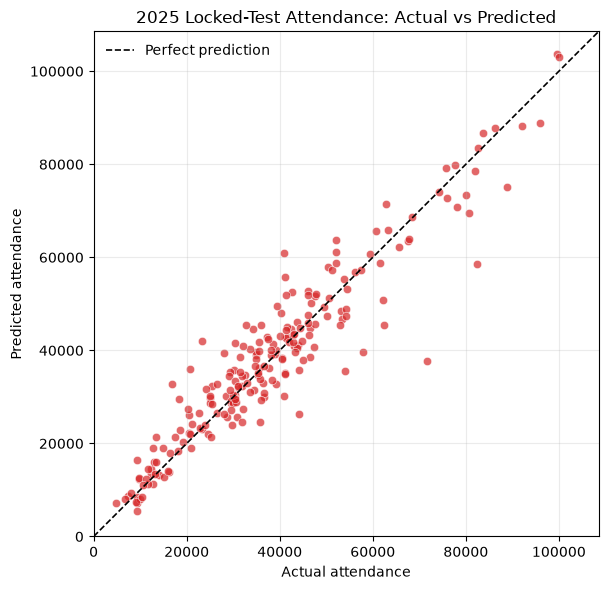

In [10]:
# Define the shared plotting range.
actual_values = (
    test_predictions_df["actual_attendance"]
    .to_numpy(dtype="float64")
)

predicted_values = (
    test_predictions_df["predicted_attendance"]
    .to_numpy(dtype="float64")
)

plot_min = float(
    min(
        actual_values.min(),
        predicted_values.min(),
    )
)

plot_max = float(
    max(
        actual_values.max(),
        predicted_values.max(),
    )
)

plot_padding = (
    plot_max - plot_min
) * 0.05

plot_lower = max(
    0,
    plot_min - plot_padding,
)

plot_upper = (
    plot_max + plot_padding
)


# Plot actual against predicted attendance.
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.scatter(
    actual_values,
    predicted_values,
    alpha=0.7,
    color="tab:red",
    edgecolor="white",
    linewidth=0.5,
)

ax.plot(
    [
        plot_lower,
        plot_upper,
    ],
    [
        plot_lower,
        plot_upper,
    ],
    linestyle="--",
    color="black",
    linewidth=1.2,
    label="Perfect prediction",
)

ax.set(
    title=(
        "2025 Locked-Test Attendance: "
        "Actual vs Predicted"
    ),
    xlabel="Actual attendance",
    ylabel="Predicted attendance",
    xlim=(plot_lower, plot_upper),
    ylim=(plot_lower, plot_upper),
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.25
)

ax.legend(
    frameon=False
)

plt.tight_layout()
plt.show()

**Final Test Interpretation**

The frozen Gradient Boosting configuration generalised successfully to the 2025 locked test season. It achieved an MAE of approximately 4,561 attendees and an RMSE of approximately 6,560 attendees.

The mean prediction error was approximately +410 attendees, indicating only a small overall tendency to overpredict. This directional bias is minor relative to the MAE, though positive and negative errors may partially offset each other.

The actual-versus-predicted plot shows that most matches follow the diagonal reference line, indicating that the model captures the overall attendance scale across low-, medium-, and high-demand fixtures. Prediction dispersion becomes wider for some medium- and high-attendance matches, with a small number of substantial underpredictions. These larger errors explain why RMSE remains higher than MAE.

Both MAE and RMSE were lower than in the 2024 validation evaluation, providing no evidence of a deterioration in one-season-ahead generalisation. However, the difference should not be interpreted as a guaranteed permanent improvement because the two seasons may have different levels of forecasting difficulty.

For matchday planning, the model is more appropriate for demand-level and resource-planning support than for producing an exact attendance count. Additional operational buffers should be retained for unusually high-demand or event-specific fixtures.

### 5.3 Prepare Post-Evaluation Diagnostics for Power BI

The locked-test prediction evidence is extended with fixed-width error bins for distribution analysis. Permutation importance is then calculated using the model trained through 2024 and the 2025 locked test data.

These diagnostics are generated only after model selection and final evaluation. They do not influence model selection, hyperparameter tuning, or the reported locked-test performance.

In [11]:
# Prepare prediction-error fields for dashboard reporting.
ERROR_BIN_WIDTH = 2_500

test_predictions_df["error_bin_start"] = (
    np.floor(
        test_predictions_df["prediction_error"]
        / ERROR_BIN_WIDTH
    )
    * ERROR_BIN_WIDTH
).astype("int64")

test_predictions_df["error_bin_label"] = [
    (
        f"{bin_start:+,.0f} to "
        f"{bin_start + ERROR_BIN_WIDTH:+,.0f}"
    )
    for bin_start
    in test_predictions_df["error_bin_start"]
]

test_predictions_df["error_direction"] = np.select(
    [
        test_predictions_df["prediction_error"].lt(0),
        test_predictions_df["prediction_error"].gt(0),
    ],
    [
        "Underprediction",
        "Overprediction",
    ],
    default="Exact prediction",
)


# Define concise feature names for dashboard display.
feature_display_names = {
    "season_year": "Season",
    "start_hour": "Start time",
    "home_team_last_5_attendance_mean": (
        "Home recent attendance"
    ),
    "away_team_last_5_attendance_mean": (
        "Away recent attendance"
    ),
    "venue_last_10_attendance_mean": (
        "Venue recent attendance"
    ),
    "home_team_last_5_win_rate": (
        "Home recent win rate"
    ),
    "away_team_last_5_win_rate": (
        "Away recent win rate"
    ),
    "home_team_last_5_score_margin_mean": (
        "Home recent score margin"
    ),
    "away_team_last_5_score_margin_mean": (
        "Away recent score margin"
    ),
    "round_label": "Round",
    "home_team": "Home team",
    "away_team": "Away team",
    "venue_name": "Venue",
    "match_month": "Match month",
    "match_day_of_week": "Day of week",
    "is_night_match": "Night match",
    "is_school_holiday": "School holiday",
}


# Calculate permutation importance on the frozen final model.
permutation_result = permutation_importance(
    estimator=final_model_pipeline,
    X=X_test,
    y=y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=30,
    random_state=42,
)


# Prepare the feature-importance table for Power BI.
feature_importance_df = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "feature_display_name": [
            feature_display_names.get(
                feature,
                feature.replace("_", " ").title(),
            )
            for feature in FEATURE_COLUMNS
        ],
        "mae_increase_mean": (
            permutation_result.importances_mean
        ),
        "mae_increase_std": (
            permutation_result.importances_std
        ),
    }
)

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "mae_increase_mean",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

feature_importance_df["importance_rank"] = (
    np.arange(
        1,
        len(feature_importance_df) + 1,
    )
)

feature_importance_df[
    [
        "mae_increase_mean",
        "mae_increase_std",
    ]
] = (
    feature_importance_df[
        [
            "mae_increase_mean",
            "mae_increase_std",
        ]
    ]
    .round(2)
)


# Validate the two diagnostic outputs.
diagnostic_columns = [
    "prediction_error",
    "error_bin_start",
    "error_bin_label",
    "error_direction",
]

if (
    len(test_predictions_df) != len(X_test)
    or test_predictions_df[
        diagnostic_columns
    ].isna().any().any()
):
    raise ValueError(
        "The locked-test diagnostic output is invalid."
    )

importance_values = feature_importance_df[
    [
        "mae_increase_mean",
        "mae_increase_std",
    ]
].to_numpy(dtype="float64")

if (
    len(feature_importance_df)
    != len(FEATURE_COLUMNS)
    or not np.isfinite(importance_values).all()
):
    raise ValueError(
        "The feature-importance output is invalid."
    )


# Preview the dashboard-ready diagnostic results.
display(
    test_predictions_df[
        [
            "match_id",
            "prediction_error",
            "error_bin_start",
            "error_bin_label",
            "error_direction",
        ]
    ].head()
)

display(
    feature_importance_df.head(8)
)

print(
    "Locked-test diagnostic rows:",
    len(test_predictions_df),
)

print(
    "Feature-importance rows:",
    len(feature_importance_df),
)

,match_id,prediction_error,error_bin_start,error_bin_label,error_direction
0,20250307_H16_A10,7822.595720,7500,"+7,500 to +10,000",Overprediction
1,20250309_H09_A04,1034.900100,0,"+0 to +2,500",Overprediction
2,20250313_H14_A03,-6717.835477,-7500,"-7,500 to -5,000",Underprediction
3,20250314_H10_A05,-11153.026848,-12500,"-12,500 to -10,000",Underprediction
4,20250315_H04_A13,2630.312952,2500,"+2,500 to +5,000",Overprediction


,feature,feature_display_name,mae_increase_mean,mae_increase_std,importance_rank
0,venue_last_10_attendance_mean,Venue recent attendance,7705.94,490.33,1
1,venue_name,Venue,1894.35,214.60,2
2,away_team,Away team,1857.62,266.19,3
3,home_team,Home team,1795.31,216.28,4
4,match_month,Match month,552.67,114.73,5
5,match_day_of_week,Day of week,490.91,95.15,6
6,home_team_last_5_score_margin_mean,Home recent score margin,481.40,78.61,7
7,away_team_last_5_attendance_mean,Away recent attendance,437.35,142.68,8


Locked-test diagnostic rows: 216
Feature-importance rows: 17


## 6. Prepare the 2026 Scoring Model and Export

### 6.1 Refit the Selected Configuration on All Historical Data

After the locked-test evaluation is complete, the 2025 matches can be incorporated into model fitting because they are now part of the available historical record.

A fresh copy of the frozen Gradient Boosting configuration is fitted on all eligible historical matches through the end of 2025. The model family, feature set, preprocessing design, and hyperparameters remain unchanged.

The 2025 test metrics reported in Section 5 remain the unbiased evidence for the modelling workflow. The newly refitted scoring model is not evaluated again on 2025 because those matches are now included in its training data.

In [12]:
# Combine all eligible historical model-development partitions.
scoring_training_df = (
    historical_df
    .loc[
        historical_df["dataset_role"].isin(
            [
                TRAINING_ROLE,
                VALIDATION_ROLE,
                LOCKED_TEST_ROLE,
            ]
        )
    ]
    .copy()
    .sort_values(
        "match_date",
        kind="stable",
    )
    .reset_index(drop=True)
)


# Confirm the complete historical coverage.
scoring_training_seasons = sorted(
    scoring_training_df["season_year"]
    .unique()
    .tolist()
)

expected_scoring_training_seasons = [
    2013,
    2014,
    2015,
    2016,
    2017,
    2018,
    2019,
    2022,
    2023,
    2024,
    2025,
]

if (
    len(scoring_training_df) != 2297
    or scoring_training_seasons
    != expected_scoring_training_seasons
):
    raise ValueError(
        "The full historical scoring-training dataset "
        "does not match the expected project design."
    )


# Construct the full historical training inputs.
X_scoring_training = (
    scoring_training_df
    .loc[:, FEATURE_COLUMNS]
    .copy()
)

y_scoring_training = (
    scoring_training_df
    .loc[:, TARGET_COLUMN]
    .astype("float64")
    .copy()
)

if y_scoring_training.isna().any():
    raise ValueError(
        "The scoring-model target contains missing values."
    )


# Create a fresh copy of the frozen model configuration.
scoring_model_pipeline = clone(
    selected_candidate_pipeline
)


# Fit the 2026 scoring model on all history through 2025.
scoring_model_pipeline.fit(
    X_scoring_training,
    y_scoring_training,
)


# Confirm that the frozen hyperparameters were preserved.
scoring_model_parameters = (
    scoring_model_pipeline
    .named_steps["model"]
    .get_params()
)

scoring_configuration_preserved = all(
    scoring_model_parameters[parameter_name]
    == selected_value
    for parameter_name, selected_value
    in selected_model_parameters.items()
)

if not scoring_configuration_preserved:
    raise ValueError(
        "The frozen configuration was not preserved "
        "in the 2026 scoring model."
    )


# Present a concise scoring-model summary.
scoring_model_summary = pd.DataFrame(
    [
        {
            "model_role": "2026 scoring model",
            "model": selected_model_name,
            "training_rows": len(
                scoring_training_df
            ),
            "trained_through": max(
                scoring_training_seasons
            ),
            "features": X_scoring_training.shape[1],
            "additional_tuning": "No",
            "configuration_preserved": (
                scoring_configuration_preserved
            ),
            "status": "Fitted",
        }
    ]
)

scoring_model_summary

,model_role,model,training_rows,trained_through,features,additional_tuning,configuration_preserved,status
0,2026 scoring model,Gradient Boosting Regressor,2297,2025,17,No,True,Fitted


### 6.2 Validate and Export the Final Artifacts

Before export, a concise set of checks confirms that the locked-test evaluation is complete, the reported metrics are finite, the frozen model configuration has been preserved, and the final scoring pipeline can generate valid predictions.

The fitted scoring pipeline and its modelling contract are saved as one local model bundle for Notebook 07. A small evaluation summary is exported separately for version-controlled reporting.

In [13]:
# Confirm that the scoring pipeline can generate predictions.
scoring_smoke_predictions = (
    scoring_model_pipeline.predict(
        X_scoring_training.head(5)
    )
)


# Define the final export-readiness checks.
final_quality_checks = {
    "Locked-test predictions": (
        len(test_predictions) == 216
        and np.isfinite(test_predictions).all()
    ),
    "Evaluation metrics": (
        np.isfinite(
            final_performance_summary[
                [
                    "mae",
                    "rmse",
                    "mean_prediction_error",
                ]
            ].to_numpy(dtype="float64")
        ).all()
    ),
    "Frozen configuration": (
        scoring_configuration_preserved
    ),
    "Scoring training coverage": (
        len(scoring_training_df) == 2297
        and max(scoring_training_seasons) == 2025
    ),
    "Scoring prediction smoke test": (
        len(scoring_smoke_predictions) == 5
        and np.isfinite(
            scoring_smoke_predictions
        ).all()
    ),
}


# Present one concise quality-check table.
final_quality_check_summary = pd.DataFrame(
    [
        {
            "check": check_name,
            "result": (
                "PASS"
                if check_passed
                else "FAIL"
            ),
        }
        for check_name, check_passed
        in final_quality_checks.items()
    ]
)

display(final_quality_check_summary)


# Stop before export if a required check failed.
if final_quality_check_summary[
    "result"
].eq("FAIL").any():
    raise RuntimeError(
        "The final Notebook 06 artifacts "
        "are not ready for export."
    )

,check,result
0,Locked-test predictions,PASS
1,Evaluation metrics,PASS
2,Frozen configuration,PASS
3,Scoring training coverage,PASS
4,Scoring prediction smoke test,PASS


The validated scoring model and evaluation results are now packaged for downstream use. The saved model contains the complete fitted preprocessing and regression pipeline together with the feature and training-data contract required by Notebook 07.

In [14]:
# Define the final output directories.
FINAL_MODEL_DIR = (
    project_root
    / "models"
    / "final"
)

MODEL_REPORT_DIR = (
    project_root
    / "reports"
    / "modeling"
)

FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Package the fitted scoring pipeline and modelling contract.
final_model_bundle = {
    "estimator": scoring_model_pipeline,
    "model_role": "2026_scoring_model",
    "model_key": selected_model_key,
    "model_name": selected_model_name,
    "selected_parameters": selected_model_parameters,
    "feature_columns": FEATURE_COLUMNS,
    "numerical_features": (
        candidate_model_bundle["numerical_features"]
    ),
    "categorical_features": (
        candidate_model_bundle["categorical_features"]
    ),
    "target_column": TARGET_COLUMN,
    "selection_metric": PRIMARY_SELECTION_METRIC,
    "training_rows": len(scoring_training_df),
    "training_seasons": scoring_training_seasons,
    "trained_through": max(
        scoring_training_seasons
    ),
    "evaluation_summary": (
        final_performance_summary
        .to_dict(orient="records")
    ),
}


# Prepare the tracked evaluation-summary table.
evaluation_export_df = (
    final_performance_summary.copy()
)

evaluation_export_df.insert(
    0,
    "model_key",
    selected_model_key,
)

evaluation_export_df.insert(
    1,
    "model_name",
    selected_model_name,
)

evaluation_export_df.insert(
    2,
    "selected_hyperparameters",
    frozen_selection[
        "selected_hyperparameters"
    ],
)


# Define the two exported artifact paths.
final_model_path = (
    FINAL_MODEL_DIR
    / "notebook_06_scoring_model.joblib"
)

evaluation_summary_path = (
    MODEL_REPORT_DIR
    / "notebook_06_final_evaluation_summary.csv"
)


# Export the fitted 2026 scoring model.
joblib.dump(
    final_model_bundle,
    final_model_path,
    compress=3,
)


# Export the validation and locked-test metrics.
evaluation_export_df.to_csv(
    evaluation_summary_path,
    index=False,
)


# Confirm that both artifacts were created.
exported_artifact_summary = pd.DataFrame(
    [
        {
            "artifact": "2026 scoring model bundle",
            "path": str(
                final_model_path.relative_to(
                    project_root
                )
            ),
            "size_kb": round(
                final_model_path.stat().st_size
                / 1024,
                1,
            ),
            "status": (
                "Created"
                if final_model_path.exists()
                else "Missing"
            ),
        },
        {
            "artifact": "Final evaluation summary",
            "path": str(
                evaluation_summary_path.relative_to(
                    project_root
                )
            ),
            "size_kb": round(
                evaluation_summary_path.stat().st_size
                / 1024,
                1,
            ),
            "status": (
                "Created"
                if evaluation_summary_path.exists()
                else "Missing"
            ),
        },
    ]
)

exported_artifact_summary

,artifact,path,size_kb,status
0,2026 scoring model bundle,models\final\notebook_06_scoring_model.joblib,184.1,Created
1,Final evaluation summary,reports\modeling\notebook_06_final_evaluation_...,0.5,Created


In [16]:
# Prepare locked-test fixture-level evidence for reporting.
locked_test_export_df = test_predictions_df.copy()

locked_test_export_df["absolute_percentage_error"] = (
    locked_test_export_df["absolute_error"]
    / locked_test_export_df["actual_attendance"]
)

locked_test_export_df["within_10_percent"] = (
    locked_test_export_df["absolute_percentage_error"]
    <= 0.10
)

locked_test_export_df["evaluation_partition"] = (
    "2025 locked test"
)

locked_test_export_df["model_key"] = selected_model_key
locked_test_export_df["model_name"] = selected_model_name
locked_test_export_df["trained_through"] = 2024


# Define the Power BI data directory.
POWER_BI_DATA_DIR = (
    project_root
    / "reports"
    / "powerbi"
    / "data"
)

POWER_BI_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Confirm that the expected export tables are available.
if (
    len(locked_test_export_df) != 216
    or len(feature_importance_df)
    != len(FEATURE_COLUMNS)
):
    raise ValueError(
        "The dashboard data does not match "
        "the expected output dimensions."
    )


# Define the four dashboard-data exports.
export_jobs = [
    (
        "Locked-test predictions (modeling)",
        locked_test_export_df,
        MODEL_REPORT_DIR
        / "notebook_06_locked_test_predictions.csv",
    ),
    (
        "Locked-test predictions (Power BI)",
        locked_test_export_df,
        POWER_BI_DATA_DIR
        / "locked_test_predictions.csv",
    ),
    (
        "Feature importance (modeling)",
        feature_importance_df,
        MODEL_REPORT_DIR
        / "notebook_06_feature_importance.csv",
    ),
    (
        "Feature importance (Power BI)",
        feature_importance_df,
        POWER_BI_DATA_DIR
        / "feature_importance.csv",
    ),
]


# Export the dashboard-ready tables.
for _, export_df, export_path in export_jobs:
    export_df.to_csv(
        export_path,
        index=False,
    )


# Present a concise export summary.
dashboard_export_summary = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "path": str(
                export_path.relative_to(project_root)
            ),
            "rows": len(export_df),
            "status": (
                "Created"
                if export_path.exists()
                else "Missing"
            ),
        }
        for artifact_name, export_df, export_path
        in export_jobs
    ]
)

display(dashboard_export_summary)


# Stop if an expected dashboard file was not created.
if dashboard_export_summary[
    "status"
].ne("Created").any():
    raise RuntimeError(
        "One or more dashboard-data exports failed."
    )

,artifact,path,rows,status
0,Locked-test predictions (modeling),reports\modeling\notebook_06_locked_test_predi...,216,Created
1,Locked-test predictions (Power BI),reports\powerbi\data\locked_test_predictions.csv,216,Created
2,Feature importance (modeling),reports\modeling\notebook_06_feature_importanc...,17,Created
3,Feature importance (Power BI),reports\powerbi\data\feature_importance.csv,17,Created


### 6.3 Conclusion, Limitations, and Next Step

**Final Model Selection and Evaluation**

Gradient Boosting Regressor was selected as the final model family after achieving the strongest performance on the untouched 2024 validation partition:

- validation MAE: approximately 5,471 attendees
- validation RMSE: approximately 7,719 attendees

The selected model family and its Notebook 05 hyperparameters were frozen before the 2025 locked test partition was accessed. The same configuration was then refitted using all eligible historical data through 2024 and evaluated once on the 2025 season.

The final locked-test results were:

- test MAE: approximately 4,561 attendees
- test RMSE: approximately 6,560 attendees
- mean prediction error: approximately +410 attendees

These results provide no evidence of a deterioration in one-season-ahead generalisation. The model captures the overall attendance scale effectively, although some medium- and high-attendance fixtures continue to produce larger errors.

After the locked-test evaluation was completed, the frozen Gradient Boosting configuration was refitted on all 2,297 eligible historical matches through 2025. This scoring model was saved for application to the 2026 fixtures in Notebook 07.

**Limitations**

- The model uses 17 structured pre-match features and does not include every event-specific influence on attendance, such as late weather changes, ticket-sales information, promotions, player availability, or unusual fixture significance.
- Final generalisation performance is measured using one locked test season. Future seasons may have different attendance patterns and levels of forecasting difficulty.
- The model produces point estimates rather than formal prediction intervals. Its outputs should support demand-level and resource-planning decisions rather than be treated as exact attendance commitments.
- Additional operational buffers remain appropriate for unusually high-demand or event-specific fixtures.  
- Permutation importance measures how strongly the model relies on each feature for predictive performance. It does not establish that a feature has a causal effect on attendance.
- Correlated predictors may share or dilute their measured importance. For example, venue identity and recent venue attendance may contain overlapping information, so their rankings should not be interpreted as independent effects.

**Next Step**

Notebook 07 will:

1. load the saved 2026 scoring-model bundle;
2. load and validate the nine confirmed fixtures in `squiggle_2026_scoring_dataset.csv`;
3. generate attendance predictions;
4. translate the predicted attendance into operational demand levels;
5. export a concise scoring summary for matchday planning.